In [1]:
import sys
import os
from pathlib import Path

package_path = Path(os.path.abspath("")).parent


Compressing the image...
Image shape: (1539, 1566)
Image is compressed.
Loaded cached masks.
Filtering masks...
Most common largest cluster size: 101 out of 123 total masks.
Chosen parameters: eps=100.0, min_samples=1
Filtering completed with chosen parameters: (np.float64(100.0), 1)


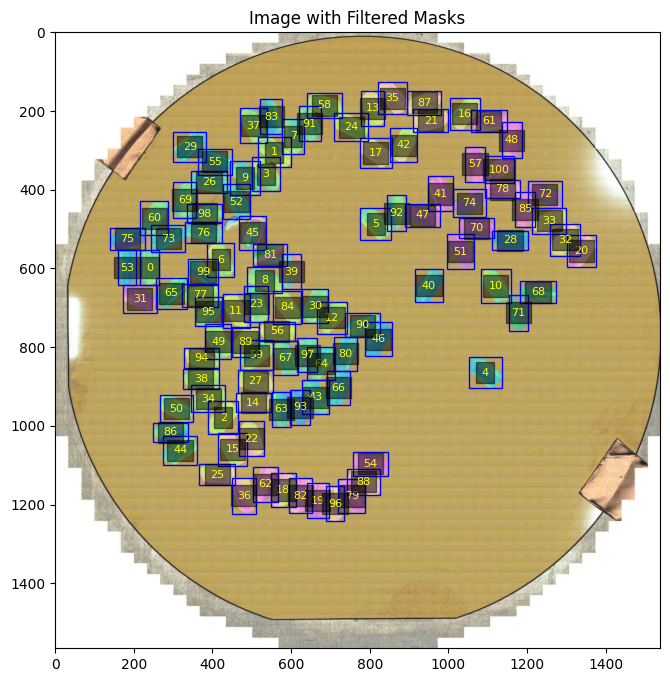

interactive(children=(IntSlider(value=0, description='index'), Output()), _dom_classes=('widget-interact',))

Number of masks identified: 101


In [2]:
from section_identification.preprocess import preprocess_image
from section_identification.filtering import filtering
from section_identification.section_detector import automatic_identification

apply_filtering = True

image1 = package_path / "images/example1.png"
image2 = package_path / "images/example2.png"
image3 = package_path / "images/example3.png"

# the weights can be downloaded from: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
checkpoint = package_path.parents[0] / "checkpoint/sam_vit_h_4b8939.pth" 

# Write filtering=True to only identify sections
masks = automatic_identification(image1, checkpoint=checkpoint, compress=True, apply_filtering=True)
print(f"Number of masks identified: {len(masks)}")

In [3]:
from section_identification.manual_detector_v2 import manual_correction

finalize_func = manual_correction(
    image1,
    masks,
    checkpoint=checkpoint,  # so we can do point prompts
    model_type="vit_h",
    device="cpu",
    overlay_opacity=0.4,
    wait_time_ms=300
)

[Info] Embedding already exists: /Users/fredericoaraujo/Documents/section_identification/images/example1_embedding.npy


[ WARN:0@0.014] global grfmt_png.cpp:695 read_chunk chunk data is too large


HTML(value="<b>Instructions:</b><br>• Hover your mouse => the model updates a preview mask after you stop movi…

/opt/anaconda3/envs/section_identification/lib/python3.9/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.lo

In [4]:
from onnx_export import install_and_export_sam_onnx

output_onnx_path = package_path / "onnx_model_.onnx"
quantized_onnx_path = package_path / "onnx_model_quantized.onnx"

final_path = install_and_export_sam_onnx(
    checkpoint=checkpoint,
    output_onnx=output_onnx_path,
    model_type="vit_h",
    return_single_mask=True,
    opset=17,
    quantize_out=quantized_onnx_path,  # if you want quantization
    gelu_approximate=False,
    use_stability_score=False,
    return_extra_metrics=False,
)
print("ONNX model saved to:", final_path)

[Info] Installing missing package 'onnxruntime-tools'...
[Info] Loading SAM model from checkpoint...


/opt/anaconda3/envs/section_identification/lib/python3.9/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.lo

[Info] Exporting ONNX model to '/Users/fredericoaraujo/Documents/section_identification/onnx_model_.onnx'...


[Info] ONNX export completed: /Users/fredericoaraujo/Documents/section_identification/onnx_model_.onnx
[Info] Quantizing model => '/Users/fredericoaraujo/Documents/section_identification/onnx_model_quantized.onnx'...
[Info] Quantization completed.
[Info] Checking exported model with onnxruntime (CPU)...
[Success] Model 'onnx_model_quantized.onnx' runs successfully with ONNXRuntime.
ONNX model saved to: /Users/fredericoaraujo/Documents/section_identification/onnx_model_quantized.onnx


In [3]:
from manual_detector import manual_correction_v2

finalize_func = manual_correction_v2(
    image_path=image1,
    generated_masks=masks,
    checkpoint=checkpoint,
    model_type="vit_h",
    device="cpu",
    display_mask_overlay=True
)

[ WARN:0@0.008] global grfmt_png.cpp:695 read_chunk chunk data is too large
/opt/anaconda3/envs/section_identification/lib/python3.9/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub 

[Info] Created embedding file: /Users/fredericoaraujo/Documents/section_identification/images/example1_embedding.npy


[ WARN:0@9.046] global grfmt_png.cpp:695 read_chunk chunk data is too large


Output()

Output()

: 

In [7]:
from segment_anything import SamPredictor
help(SamPredictor)

Help on class SamPredictor in module segment_anything.predictor:

class SamPredictor(builtins.object)
 |  SamPredictor(sam_model: segment_anything.modeling.sam.Sam) -> None
 |  
 |  Methods defined here:
 |  
 |  __init__(self, sam_model: segment_anything.modeling.sam.Sam) -> None
 |      Uses SAM to calculate the image embedding for an image, and then
 |      allow repeated, efficient mask prediction given prompts.
 |      
 |      Arguments:
 |        sam_model (Sam): The model to use for mask prediction.
 |  
 |  get_image_embedding(self) -> torch.Tensor
 |      Returns the image embeddings for the currently set image, with
 |      shape 1xCxHxW, where C is the embedding dimension and (H,W) are
 |      the embedding spatial dimension of SAM (typically C=256, H=W=64).
 |  
 |  predict(self, point_coords: Optional[numpy.ndarray] = None, point_labels: Optional[numpy.ndarray] = None, box: Optional[numpy.ndarray] = None, mask_input: Optional[numpy.ndarray] = None, multimask_output: bool 